In [ ]:
import torch
from sklearn.datasets import fetch_california_housing
from src.mssp import MSSP
import matplotlib.pyplot as plt
import time
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
RANDOM_SEED = 42

In [3]:
if RANDOM_SEED is not None:
    torch.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed(RANDOM_SEED)

data = fetch_california_housing()
X = torch.tensor(data.data, dtype=torch.double)
y = torch.tensor(data.target, dtype=torch.double)

i = torch.randperm(len(X))
i_train = i[:int(len(X)*0.8)]
i_valid = i[int(len(X)*0.8):int(len(X)*0.9)]
i_test = i[int(len(X)*0.9):]

X_train, y_train = X[i_train], y[i_train]
X_valid, y_valid = X[i_valid], y[i_valid]
X_test, y_test = X[i_test], y[i_test]

In [4]:
# data = pd.read_csv("spy.csv")
# X = torch.tensor(data.drop(columns=['target']).values, dtype=torch.double)
# y = torch.tensor(data['target'].values, dtype=torch.double)
# X_train, y_train, close_train, X_valid, y_valid, close_valid, X_test, y_test, close_test = get_spy()

In [5]:
mae_scores = []
for i in range(1, 11):
    mssp = MSSP(
        n_best=100, 
        loss_fn="mse", 
        random_seed=42, 
        epochs=i, 
        diversity_ratio=0.75, 
        pow_cross=True,
    )

    st_ft = time.time()
    mssp.fit(X_train, y_train)
    et_fr = time.time()
    for k in (1, 4, 16, 32):
        st_pr = time.time()
        mssp_pred = mssp.predict(X_test, top_k=k)
        et_pr = time.time()
        mask = ~mssp_pred.isnan()
        mae = mean_absolute_error(mssp_pred[mask], y_test[mask])
        mae_scores.append(('mssp', i, k, mae, et_fr - st_ft, et_pr - st_pr))

loss (mse): 0.6163414716720581 epoch: 0 , time: 0.90s
Best loss: 0.6163414716720581 after training for 0 epochs
loss (mse): 0.6163414716720581 epoch: 0 , time: 0.38s
loss (mse): 0.5465952754020691 epoch: 1 , time: 1.71s
Best loss: 0.5465952754020691 after training for 1 epochs
loss (mse): 0.6163414716720581 epoch: 0 , time: 0.46s
loss (mse): 0.5465952754020691 epoch: 1 , time: 1.27s
loss (mse): 0.5021675229072571 epoch: 2 , time: 0.87s
Best loss: 0.5021675229072571 after training for 2 epochs
loss (mse): 0.6163414716720581 epoch: 0 , time: 0.39s
loss (mse): 0.5465952754020691 epoch: 1 , time: 0.88s
loss (mse): 0.5021675229072571 epoch: 2 , time: 1.12s
loss (mse): 0.45580747723579407 epoch: 3 , time: 1.11s
Best loss: 0.45580747723579407 after training for 3 epochs
loss (mse): 0.6163414716720581 epoch: 0 , time: 0.40s
loss (mse): 0.5465952754020691 epoch: 1 , time: 0.90s
loss (mse): 0.5021675229072571 epoch: 2 , time: 1.14s
loss (mse): 0.45580747723579407 epoch: 3 , time: 0.88s
loss (mse

In [6]:
linreg_model = LinearRegression()
st_ft = time.time()
linreg_model.fit(X_train, y_train)
et_ft = time.time()

In [7]:
st_pr = time.time()
linreg_pred = torch.tensor(linreg_model.predict(X_test), dtype=torch.double)
et_pr = time.time()
mae_raw = mean_absolute_error(linreg_pred, y_test)

In [8]:
mae_scores.append(("lin", 1, 1, mae_raw, et_ft - st_ft, et_pr - st_pr))

In [11]:
df = pd.DataFrame(mae_scores)
df.columns = ['model', 'epochs', 'n_models', 'mae', 'fit_time', 'pred_time']
df = df.sort_values('mae')
df = df.reset_index(drop=True)

In [12]:
df

,model,epochs,n_models,mae,fit_time,pred_time
0,mssp,10,1,0.442825,10.432796,0.290784
1,mssp,10,4,0.442966,10.432796,0.693037
2,mssp,10,16,0.443168,10.432796,4.031186
3,mssp,9,16,0.443176,9.889256,1.686876
4,mssp,10,32,0.443944,10.432796,5.083432
5,mssp,9,4,0.444496,9.889256,0.356365
6,mssp,9,1,0.446404,9.889256,0.109291
7,mssp,9,32,0.446960,9.889256,2.723960
8,mssp,8,4,0.447452,7.781518,0.169423
9,mssp,8,16,0.447752,7.781518,0.997409


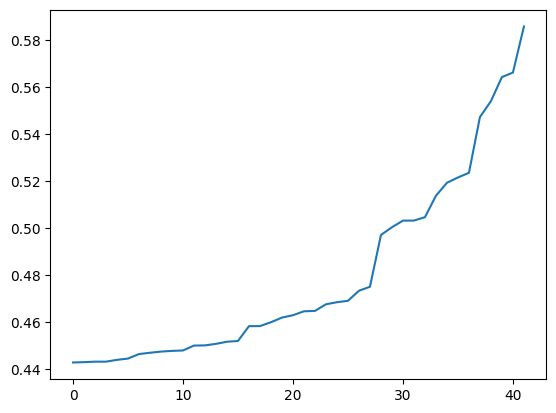

In [ ]:
plt.plot(df['mae'].values)
# plt.axvline(27, color='red', linewidth=0.25)
# plt.text(27, plt.ylim()[0], '27', color='red', ha='center', va='top', alpha=0.5, fontsize=10, fontweight='light')

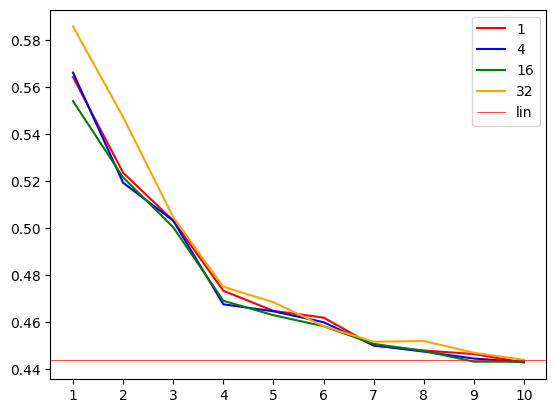

In [ ]:
k1 = df[(df['n_models'] == 1) & (df['model'] == 'mssp')].sort_values('epochs')
k4 = df[df['n_models'] == 4].sort_values('epochs')
k16 = df[df['n_models'] == 16].sort_values('epochs')
k32 = df[df['n_models'] == 32].sort_values('epochs')

x_labels = list(range(1, 11))
x_range = list(range(10))

plt.plot(k1['mae'].values, color='red', label='1')
plt.plot(k4['mae'].values, color='blue', label='4')
plt.plot(k16['mae'].values, color='green', label='16')
plt.plot(k32['mae'].values, color='orange', label='32')
plt.xticks(x_range, x_labels)
plt.axhline(mae, color = 'red', linewidth=0.5, label='lin')
plt.legend()

### TODO: also test with different number of n_best

<Axes: >

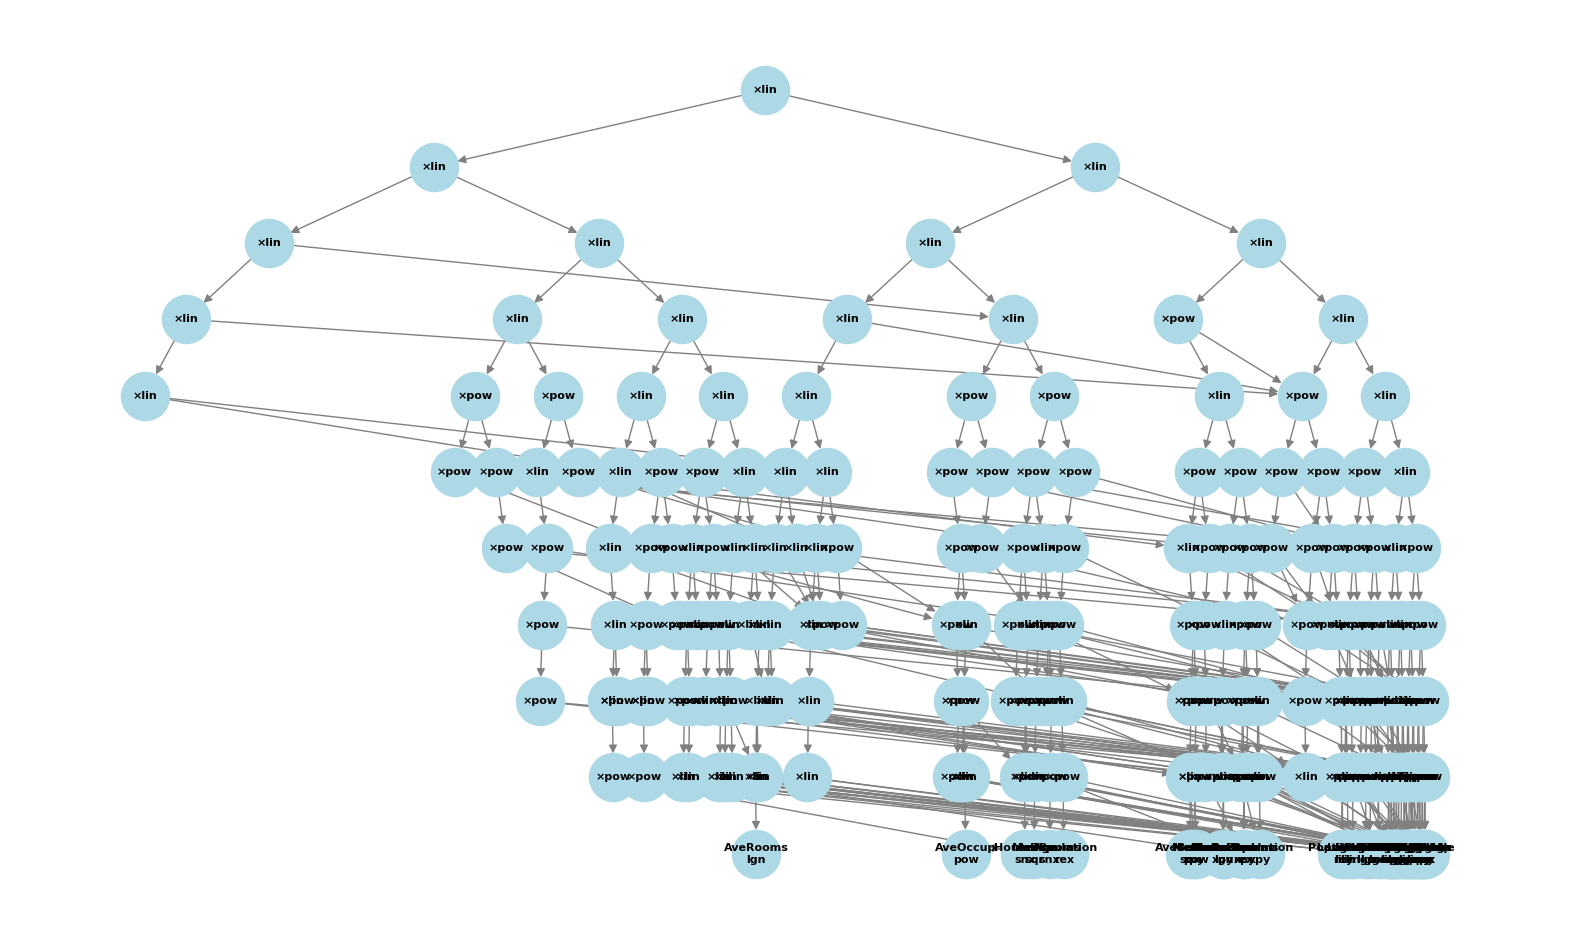

In [ ]:
mssp.plot_graph(1, colnames=data.feature_names)